In [1]:
import json


def contar_lineas(filename):
    count = 0
    with open(filename, "rb") as f:
        for bloque in iter(lambda: f.read(1024*1024), b""):
            count += bloque.count(b">")
    return count

#tabla informativa de Trembl
TABLE_file = "../Data2/Trembl/table"
#print(contar_lineas(filename))
#253,061,697 elementos en tabla informativa Trembl

#ALL SEQUENCES
PROTEIN_FIle= "../Data2/Trembl/all"
#print(contar_lineas(PROTEIN_FIle))
# 253,061,697 sq in fasta format

TFS_file= "../Data2/Trembl/TFs"
#print(contar_lineas(filename))
#10,551,204 secuencias de todo el Trembl

In [2]:
##%% LOCAL PATH
import time

data_path = '../Data2/Swissprot/'

##%% DATA READING

import numpy as np
from Bio import SeqIO
from sklearn.model_selection import train_test_split

def read_fasta_data(fasta_file):
    result = []
    seq_ids = []
    fp = open(fasta_file, 'r')
    for seq_record in SeqIO.parse(fp, 'fasta'):
        seq = seq_record.seq
        seq_id = seq_record.id
        seqs = seq_id.split('|')
        seq_id_short = seqs[-1].replace(" ","")
        #if seq_id_short in on_type:
        if len(seq) <= 1000:
            result.append(str(seq))
            seq_ids.append(seq_id)

                #print(seq_id_short, seq_id)
    fp.close()
    return result, seq_ids

seq_tfs, seq_tfs_ids = read_fasta_data(data_path + "TFS.fasta")
seq_notfs, seq_notfs_ids = read_fasta_data(data_path + "Not_TFS.fasta")

print(len(seq_tfs))
print(len(seq_notfs))

22418
531974


In [3]:
import json
with open("Trembl_TFS_fasta.json", "r") as f:
    seq_tfsA = json.load(f)

with open("Trembl_Not_TFS_Fasta.json", "r") as f:
    seq_not_tfsA = json.load(f)
    
print(len(seq_tfsA))
print(len(seq_not_tfsA))

with open("Trembl_TFS_ids_fasta.json", "r") as f:
    seq_tfs_idsA = json.load(f)

with open("Trembl_Not_TFS_ids_Fasta.json", "r") as f:
    seq_not_tfs_idsA = json.load(f)

print(len(seq_tfs_idsA))
print(len(seq_not_tfs_idsA))

28913
1254490
28913
1254490


In [4]:
comunes = set(seq_notfs_ids) & set(seq_not_tfs_idsA) 
print(comunes)  

set()


In [5]:
seq_tfs = seq_tfs + seq_tfsA 
seq_tfs_ids = seq_tfs_ids + seq_tfs_idsA
print(len(seq_tfs))
print(seq_tfs_ids[24412])

51331
A0A2R8P0K0


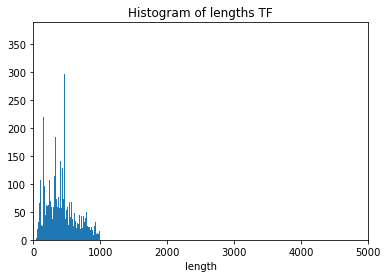

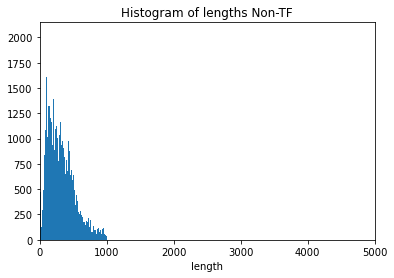

319.90470962866607 414.59942335041205


In [6]:
##%% PLOT LENGTH GENERATOR

import matplotlib.pyplot as plt
from statistics import mean

lengths_tfs = [len(t) for t in seq_tfs]
plt.hist(lengths_tfs , bins = len(set(lengths_tfs)))
plt.title('Histogram of lengths TF')
plt.xlabel('length')
plt.xlim(0, 5000)
plt.show()

lengths_notfs = [len(t) for t in seq_notfs]
plt.hist(lengths_notfs , bins = len(set(lengths_notfs)))
plt.title('Histogram of lengths Non-TF')
plt.xlabel('length')
plt.xlim(0, 5000)
plt.show()
print(mean(lengths_notfs), mean(lengths_tfs))

In [7]:
##%% Conteo de aminoacidos

def amino_count(sequences):

  amino_input = set()
  amino2count = {}

  for seq in sequences:

    seq_1 = list(seq)

    for amino in seq_1:
      if amino not in amino_input:
        amino_input.add(amino)
        amino2count[amino] = 1
      else:
        amino2count[amino] += 1

  return amino2count

amino2count_tf = amino_count(seq_tfs)
amino2count_notf = amino_count(seq_notfs)

print('Aminoacids present in tf dataset: ', amino2count_tf)
print('Aminoacids present in notf dataset: ', amino2count_notf)


Aminoacids present in tf dataset:  {'M': 506993, 'S': 1851336, 'L': 1909605, 'E': 1470363, 'T': 1108770, 'R': 1241149, 'D': 1058393, 'Y': 577788, 'N': 835412, 'I': 929869, 'G': 1413882, 'Q': 1055002, 'A': 1583002, 'F': 719013, 'V': 1160600, 'H': 601629, 'C': 400440, 'K': 1217347, 'P': 1439104, 'W': 191416, 'X': 10687, 'Z': 1, 'B': 2}
Aminoacids present in notf dataset:  {'M': 4197383, 'S': 10738402, 'L': 16511195, 'E': 11318135, 'Q': 6437228, 'K': 9841709, 'G': 12331844, 'A': 14494397, 'D': 9308054, 'I': 10294091, 'N': 6749000, 'T': 9022127, 'P': 7842536, 'R': 9427781, 'V': 11924275, 'H': 3839009, 'Y': 5023463, 'F': 6690925, 'W': 1913291, 'C': 2267944, 'U': 324, 'X': 7327, 'Z': 246, 'B': 273, 'O': 29}


,Amino,Values
12,A,1583002
22,B,2
16,C,400440
6,D,1058393
3,E,1470363
13,F,719013
10,G,1413882
15,H,601629
9,I,929869
17,K,1217347


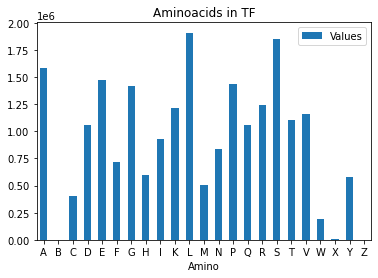

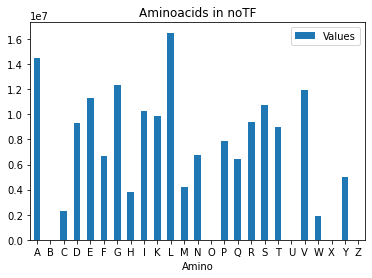

In [8]:
def histograms(amino2count_tf, amino2count_notf):
    
    import pandas as pd
    
    amino_tf = pd.DataFrame(list(amino2count_tf.items()) , columns = ['Amino', 'Values'])
    amino_tf = amino_tf.sort_values(by = ['Amino'], ascending = True)
    ax = amino_tf.plot.bar(x = 'Amino', y = 'Values', rot = 0, title = 'Aminoacids in TF')
    
    amino_notf = pd.DataFrame(list(amino2count_notf.items()) , columns = ['Amino', 'Values'])
    amino_notf = amino_notf.sort_values(by = ['Amino'])
    ax = amino_notf.plot.bar(x = 'Amino', y = 'Values', rot = 0, title = 'Aminoacids in noTF')
    
    return amino_tf

histograms(amino2count_tf, amino2count_notf)

Aminoacids present in tf dataset after cleaning:  {'M': 506928, 'S': 1851067, 'L': 1909348, 'E': 1470222, 'T': 1108645, 'R': 1241040, 'D': 1058282, 'Y': 577717, 'N': 835322, 'I': 929786, 'G': 1413707, 'Q': 1054892, 'A': 1582810, 'F': 718922, 'V': 1160470, 'H': 601569, 'C': 400377, 'K': 1217193, 'P': 1438886, 'W': 191398, 'X': 10687}
Aminoacids present in notf dataset after cleaning:  {'M': 4194457, 'S': 10731358, 'L': 16501111, 'E': 11311331, 'Q': 6433416, 'K': 9835347, 'G': 12323204, 'A': 14485595, 'D': 9302832, 'I': 10288191, 'N': 6744755, 'T': 9016567, 'P': 7836850, 'R': 9422724, 'V': 11916642, 'H': 3836548, 'Y': 5020076, 'F': 6686291, 'W': 1912009, 'C': 2265626, 'X': 7190}


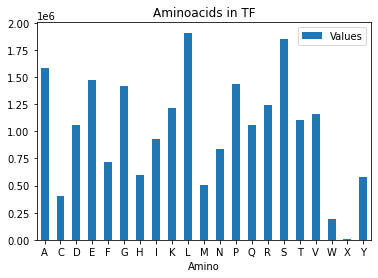

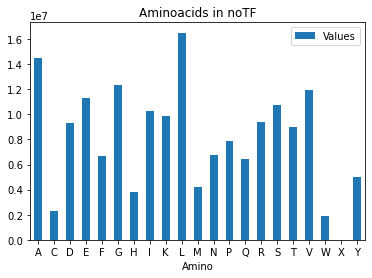

In [9]:
##%% Limpieza de secuencias. Filtro de: (B,O,U,Z)

def cleaning_sequence(sequence):

    clean_seq_tfs = []
    
    for seq in sequence:
        
        seq_1 = list(seq)
    
        if not any(amino in seq_1 for amino in ('B','O','U','Z')):
            clean_seq_tfs.append(seq)
            
    return clean_seq_tfs

clean_seq_tfs = cleaning_sequence(seq_tfs)
clean_seq_notfs = cleaning_sequence(seq_notfs)

clean_amino2count_tf = amino_count(clean_seq_tfs)
clean_amino2count_notf = amino_count(clean_seq_notfs)

print('Aminoacids present in tf dataset after cleaning: ', clean_amino2count_tf)
print('Aminoacids present in notf dataset after cleaning: ', clean_amino2count_notf)

clean_amino_tf = histograms(clean_amino2count_tf, clean_amino2count_notf)

In [10]:
##%% Tokenization and example

from tensorflow.keras.preprocessing.text import Tokenizer
import re

to_exclude = '!"#$%&()*+,-./:;<=>?@[\\]^`{|}~\t\n',
to_include = '_'

amino_names = list(clean_amino_tf['Amino'])
print('Aminoacids present in dataset: ', amino_names)
print('Number of different aminoacids: ', len(amino_names))

tokenizer = Tokenizer(num_words = len(amino_names), char_level = True)#, filters=to_exclude)

print(amino_names)

tokenizer.fit_on_texts(amino_names)

print('Aminoacids tokenization: ', tokenizer.word_index)
print('Number of aminoacids tokenized: ', len(tokenizer.word_index))

example_tokenized = tokenizer.texts_to_sequences([clean_seq_tfs[0]]) #str to list
print('Example of tfs sequence: ', clean_seq_tfs[0])
print('Example of tfs sequence tokenized: ', example_tokenized)
print(type(example_tokenized[0][0]))
example_tokenized = [0 if x>21 else x for x in example_tokenized[0] ]
print('Example of tfs sequence tokenized: ', example_tokenized)


##%% SAVING TOKENIZER

import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

    
##%% LOADING TOKENIZER

import pickle
with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)
    

Aminoacids present in dataset:  ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'X', 'Y']
Number of different aminoacids:  21
['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'X', 'Y']
Aminoacids tokenization:  {'a': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'k': 9, 'l': 10, 'm': 11, 'n': 12, 'p': 13, 'q': 14, 'r': 15, 's': 16, 't': 17, 'v': 18, 'w': 19, 'x': 20, 'y': 21}
Number of aminoacids tokenized:  21
Example of tfs sequence:  MSLEETLRSLSLDYLNLLINGQAFSDVTFQVEGRLVHAHRCILAARSLFFRKFFCGPDPPSGLDPIGGGSSRQPTVRPGVIPVNSVGYEVFLLLLQFLYSGQVSIVPQKHEPRPNCGERGCWHTHCTSAVDLALDTLAAARYFGVEQLALLTQKQLVSMVEKASIDDVMKVLIASRKQEMPQLWTTCSHLVAKSGLPPEILAKHLSIDVVAKIEELRLKSSLARRSLMPLHHHHHHHHHHDFGDLEDQKIRRMRRALDSSDVELVKLMVMGEGLNLDEALALHYAVENCSREVVKALLELGAADVNYPAGPAGKTSLHVAAEMVSPEMVAVLLDHHADPTVRTVDGVTPLDILRTLTSDFLFKGAVPGLNHIEPNKLRLCLELVQSAALVLSREENNASNNNNNNNNASSSAAPVYPPMSEDHSSSSSGNNNNNNNSIGNLNLDSRLVYLN

In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences 
from tensorflow.keras.utils import to_categorical
import random

def get_sequences(tokenizer , database):
  sequences_token = tokenizer.texts_to_sequences(database)
  for seq in sequences_token:
        pos = 0
        for x in seq:
            if x > 21:
                seq[pos] = 0
            pos +=1
        
  
  sequences_padded = pad_sequences(sequences_token, truncating = 'post', 
                                   padding = 'post', maxlen = 1000)
  sequences_encoded = to_categorical(sequences_padded) #one hot
  return sequences_encoded

padded_seq_tfs = get_sequences(tokenizer , clean_seq_tfs)

print('Size of full tfs dataset sequence padded: ', padded_seq_tfs.shape)
print('Length of padded example: ', len(padded_seq_tfs[0]))
#print('Example of tfs sequence padded: ', clean_seq_tfs[37770])
#print('Example of tfs sequence padded: ', padded_seq_tfs[37770][-6:])
#print('Example of tfs sequence padded: ', padded_seq_tfs[37770][80:100])
print(len(padded_seq_tfs))
random_clean_seq_notfs = random.choices(clean_seq_notfs, k=len(padded_seq_tfs)*4)
#padded_seq_notfs = get_sequences(tokenizer , clean_seq_notfs[0:35000])
padded_seq_notfs = get_sequences(tokenizer , random_clean_seq_notfs)

print('Size of full notfs dataset sequence padded: ', padded_seq_notfs.shape)
print('Length of padded example: ', len(padded_seq_notfs[0]))

Size of full tfs dataset sequence padded:  (51328, 1000, 21)
Length of padded example:  1000
51328
Size of full notfs dataset sequence padded:  (205312, 1000, 21)
Length of padded example:  1000


In [12]:
##%% Concatenation and generating labels
# WARNING OF CRASH OF RAM !!!!!!!!!!

seq_full = np.concatenate((padded_seq_tfs , padded_seq_notfs))

#[tfs][label]+[notfs][labels]
# ABCBCBB 1
# ANABABABA 35001
#--
# 1 -1
# 0 -3500014

print('Size of full database concatenated: ', seq_full.shape)

labels_ones = np.ones((padded_seq_tfs.shape[0],), dtype = int)
labels_zeros = np.zeros((padded_seq_notfs.shape[0],), dtype = int)
labels = np.concatenate ((labels_ones , labels_zeros))
print('Size of labels vector: ', labels.shape)

##%% DATA SPLIT

X_train, X_test, y_train, y_test = train_test_split(seq_full, labels, test_size = 0.1, 
                                                      random_state = 1, shuffle = True)

X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size = 0.1, 
                                                      random_state = 1, shuffle = True)

print('X_train shape:',X_train.shape, type(X_train))
print('y_train shape:',y_train.shape, type(y_train))

print('X_test shape:',X_test.shape, type(X_test))
print('y_test shape:',y_test.shape, type(y_test))

print('X_valid shape:',X_valid.shape, type(X_valid))
print('y_valid shape:',y_valid.shape, type(y_valid))


Size of full database concatenated:  (256640, 1000, 21)
Size of labels vector:  (256640,)
X_train shape: (207878, 1000, 21) <class 'numpy.ndarray'>
y_train shape: (207878,) <class 'numpy.ndarray'>
X_test shape: (25664, 1000, 21) <class 'numpy.ndarray'>
y_test shape: (25664,) <class 'numpy.ndarray'>
X_valid shape: (23098, 1000, 21) <class 'numpy.ndarray'>
y_valid shape: (23098,) <class 'numpy.ndarray'>


In [13]:
##%% CLEANING RAM

del seq_full

##%% TENSOR COVERSION

import tensorflow as tf
X_train_tensor = tf.expand_dims(X_train, -1)
X_valid_tensor = tf.expand_dims(X_valid, -1)
y_train_tensor = tf.expand_dims(y_train, -1)
y_valid_tensor = tf.expand_dims(y_valid, -1)


print('X_train_tensor shape:',X_train_tensor.shape, type(X_train_tensor))
print('y_train_tensor shape:',y_train_tensor.shape, type(y_train_tensor))

print('X_valid_tensor shape:',X_valid_tensor.shape, type(X_valid_tensor))
print('y_valid_tensor shape:',y_valid_tensor.shape, type(y_valid_tensor))

##%% CLEANING RAM
l_train = len(X_train)

del X_train, X_valid, y_train, y_valid


X_train_tensor shape: (207878, 1000, 21, 1) <class 'tensorflow.python.framework.ops.EagerTensor'>
y_train_tensor shape: (207878, 1) <class 'tensorflow.python.framework.ops.EagerTensor'>
X_valid_tensor shape: (23098, 1000, 21, 1) <class 'tensorflow.python.framework.ops.EagerTensor'>
y_valid_tensor shape: (23098, 1) <class 'tensorflow.python.framework.ops.EagerTensor'>


In [14]:
#########################################################################################################
##%% MECANISMO DE ATENCION:
#########################################################################################################

from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

class Attention_A2(Layer):
    
    def __init__(self, return_sequences = True):
        self.return_sequences = return_sequences
        super(Attention_A2,self).__init__()
 
    def build(self,input_shape):
        self.W=self.add_weight(name='attention_weight', shape=(input_shape[-1],1), 
                                initializer='random_normal', trainable=True)
        self.b=self.add_weight(name='attention_bias', shape=(input_shape[1],1), 
                                initializer='zeros', trainable=True)        
        super(Attention_A2, self).build(input_shape)
 
    def call(self,x):
        # Alignment scores. Pass them through tanh function
        e = K.tanh(K.dot(x,self.W)+self.b)
        # Remove dimension of size 1
        e = K.squeeze(e, axis=-1)   
        # Compute the weights
        alpha = K.softmax(e)
        # Reshape to tensorFlow format
        alpha = K.expand_dims(alpha, axis=-1)
        # Compute the context vector
        context = x * alpha
        context = K.sum(context, axis=1)
        return context
    
    def get_config(self):
        config = super().get_config().copy()
        config.update({
            'return_sequences': self.return_sequences 
        })
        return config

In [15]:
##%% CNN MODEL BASED ON DEEPTFACTOR

from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Activation, Flatten, Concatenate, concatenate, Input
from keras.layers import Conv2D, MaxPooling2D, MaxPooling3D, GlobalMaxPooling2D
from keras.layers import BatchNormalization
from keras.utils.vis_utils import plot_model
from tensorflow.keras import regularizers

from tensorflow.keras import layers
from keras.layers import TimeDistributed

class CNN_LSTM:
    
    def loading():
        
        initial_learning_rate = 0.001
        ###################### FIRST CNN #####################################
        model_1 = Sequential()
        
        model_1.add(Conv2D(128, (4, 21), input_shape = X_train_tensor.shape[1:]))
        model_1.add(BatchNormalization())
        model_1.add(Activation('relu'))
        model_1.add(Dropout(0.2))
        
        model_1.add(Conv2D(128, (4, 1)))
        model_1.add(BatchNormalization())
        model_1.add(Activation('relu'))
        model_1.add(Dropout(0.5))
        
        model_1.add(Conv2D(128, (16, 1)))
        model_1.add(BatchNormalization())
        model_1.add(Activation('relu'))
        model_1.add(Dropout(0.7))
        
        ###################### SECOND CNN #####################################
        
        model_2 = Sequential()
        
        model_2.add(Conv2D(128, (12, 21), input_shape = X_train_tensor.shape[1:]))
        model_2.add(BatchNormalization())
        model_2.add(Activation('relu'))
        model_2.add(Dropout(0.2))
        
        model_2.add(Conv2D(128, (8, 1)))
        model_2.add(BatchNormalization())
        model_2.add(Activation('relu'))
        model_2.add(Dropout(0.5))
        
        model_2.add(Conv2D(128, (4, 1)))
        model_2.add(BatchNormalization())
        model_2.add(Activation('relu'))
        model_2.add(Dropout(0.7))
        
        ###################### THIRD CNN #####################################
        
        model_3 = Sequential()
        
        model_3.add(Conv2D(128, (16, 21), input_shape = X_train_tensor.shape[1:]))
        model_3.add(BatchNormalization())
        model_3.add(Activation('relu'))
        model_3.add(Dropout(0.2))
        
        model_3.add(Conv2D(128, (4, 1)))
        model_3.add(BatchNormalization())
        model_3.add(Activation('relu'))
        model_3.add(Dropout(0.5))
        
        model_3.add(Conv2D(128, (4, 1)))
        model_3.add(BatchNormalization())
        model_3.add(Activation('relu'))
        model_3.add(Dropout(0.7))
        
        ###################### FOURTH CNN #####################################
        
        model_4 = Sequential()
        
        model_4.add(Conv2D(128, (6, 21), input_shape = X_train_tensor.shape[1:]))
        model_4.add(BatchNormalization())
        model_4.add(Activation('relu'))
        model_4.add(Dropout(0.2))
        
        model_4.add(Conv2D(128, (6, 1)))
        model_4.add(BatchNormalization())
        model_4.add(Activation('relu'))
        model_4.add(Dropout(0.5))
        
        model_4.add(Conv2D(128, (12, 1)))
        model_4.add(BatchNormalization())
        model_4.add(Activation('relu'))
        model_4.add(Dropout(0.7))
        
                
        ###################### FIFTH CNN #####################################
        """
        model_5 = Sequential()
        
        model_5.add(Conv2D(128, (12, 21), input_shape = X_train_tensor.shape[1:]))
        model_5.add(BatchNormalization())
        model_5.add(Activation('relu'))
        model_5.add(Dropout(0.4))
        
        model_5.add(Conv2D(128, (8, 1)))
        model_5.add(BatchNormalization())
        model_5.add(Activation('relu'))
        model_5.add(Dropout(0.6))
        
        model_5.add(Conv2D(128, (4, 1)))
        model_5.add(BatchNormalization())
        model_5.add(Activation('relu'))
        model_5.add(Dropout(0.8))
    
    
        """
        ###################### CONCATENATION AND LSTM #################################
        
        merge = Concatenate()([model_1.output, model_2.output, model_3.output, model_4.output])
        #merge = Concatenate()([model_1.output, model_2.output])
        
        merge_1 = Conv2D(512, (1, 1))(merge)
        merge_2 = BatchNormalization()(merge_1)
        merge_3 = Activation('relu')(merge_2)
        merge_4 = MaxPooling2D(pool_size = (2, 1))(merge_3)        
        
        # https://stackoverflow.com/questions/52936132/4d-input-in-lstm-layer-in-keras
        
        lstm_1 = TimeDistributed(Flatten(input_shape = (1,512)))(merge_4)
        lstm_2 = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128))(lstm_1)
        output = tf.keras.layers.Dense(1, kernel_regularizer = 'L2', activation = 'sigmoid')(lstm_2)
        
        #lstm_1 = TimeDistributed(Flatten(input_shape = (1,512)))(merge_4)
        #lstm_2 = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(512, return_sequences = True))(lstm_1)
        #attn_1 = Attention_A2()(lstm_2)
        #output = tf.keras.layers.Dense(1, kernel_regularizer = 'l2', activation = 'sigmoid')(lstm_2)

        ###################### MODEL #####################################
        
        model = Model(inputs = [model_1.input, model_2.input, model_3.input, model_4.input], outputs = output)
        
        #model = Model(inputs = [model_1.input, model_2.input], outputs = output)
        opt = keras.optimizers.Adam(learning_rate = 0.001)
        #opt = keras.optimizers.SGD(learning_rate = initial_learning_rate)
        model.compile(loss = 'binary_crossentropy',
                      optimizer = opt,
                      metrics = ['accuracy', 'AUC', 'Precision','Recall', 'TrueNegatives', 'TruePositives', 'FalseNegatives','FalsePositives'])
        
        return model
    
##%%


In [16]:
import math
def step_decay(epoch):
    initial_lrate = 0.1
    drop = 0.5
    epochs_drop = 8.0
    lrate = initial_lrate * math.pow(drop,  
           math.floor((1+epoch)/epochs_drop))
    return lrate


class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
        self.lr = []
 
    def on_epoch_end(self, batch, logs={}):
        self.losses.append(logs.get('loss'))
        self.lr.append(step_decay(len(self.losses)))

In [17]:
###################### SAVING SUMMARY ###################################model = CNN_LSTM.loading()
model = CNN_LSTM.loading()
model.summary()

from contextlib import redirect_stdout

with open('model_summary.txt', 'w') as f:
    with redirect_stdout(f):
        model.summary()

plot_model(model, to_file = 'model_figure_CNN_LSTM.png', show_shapes = True)

#% decay calc
def lr_time_based_decay(epoch, lr):
    return lr * 1 / (1 + decay * epoch)


##%% TRAINING
# initial_learning_rate = 0.01
# l0 = initial_learning_rate
batch_size = 64
epochs = 50
#decay = initial_learning_rate / epochs 
loss_history = LossHistory()
lrate = tf.keras.callbacks.LearningRateScheduler(step_decay)
t0 = time.time()


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                              patience=5, min_lr=0.00001, verbose = 1)

estop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, verbose=1)

# model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
#     'saved_model.h5',
#     save_weights_only=True,
#     monitor='val_loss',
#     mode='min',
#     verbose=1,
#     save_best_only=True)

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    'saved_model3.h5',
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    verbose=1,
    save_best_only=True)

h = model.fit([X_train_tensor,X_train_tensor,X_train_tensor,X_train_tensor], y_train_tensor,
                    batch_size = batch_size,
                    epochs = epochs,
                    verbose = 1,
                    validation_data = ([X_valid_tensor,X_valid_tensor,X_valid_tensor,X_valid_tensor], y_valid_tensor),
                    callbacks=[reduce_lr, estop, model_checkpoint_callback]
                    #callbacks = [model_checkpoint_callback, estop]
                    )
t1 = time.time()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 conv2d_input (InputLayer)      [(None, 1000, 21, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_3_input (InputLayer)    [(None, 1000, 21, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_6_input (InputLayer)    [(None, 1000, 21, 1  0           []                               
                                )]                                                            

 dropout_7 (Dropout)            (None, 982, 1, 128)  0           ['activation_7[0][0]']           
                                                                                                  
 dropout_10 (Dropout)           (None, 990, 1, 128)  0           ['activation_10[0][0]']          
                                                                                                  
 conv2d_2 (Conv2D)              (None, 979, 1, 128)  262272      ['dropout_1[0][0]']              
                                                                                                  
 conv2d_5 (Conv2D)              (None, 979, 1, 128)  65664       ['dropout_4[0][0]']              
                                                                                                  
 conv2d_8 (Conv2D)              (None, 979, 1, 128)  65664       ['dropout_7[0][0]']              
                                                                                                  
 conv2d_11

Epoch 3/50
3249/3249 [==============================] - ETA: 0s - loss: 0.1587 - accuracy: 0.9480 - auc: 0.9717 - precision: 0.9051 - recall: 0.8257 - true_negatives: 162811.0000 - true_positives: 34249.0000 - false_negatives: 7229.0000 - false_positives: 3589.0000
Epoch 3: val_accuracy did not improve from 0.95121
3249/3249 [==============================] - 822s 253ms/step - loss: 0.1587 - accuracy: 0.9480 - auc: 0.9717 - precision: 0.9051 - recall: 0.8257 - true_negatives: 162811.0000 - true_positives: 34249.0000 - false_negatives: 7229.0000 - false_positives: 3589.0000 - val_loss: 0.6596 - val_accuracy: 0.7211 - val_auc: 0.9630 - val_precision: 0.4163 - val_recall: 0.9760 - val_true_negatives: 12141.0000 - val_true_positives: 4515.0000 - val_false_negatives: 111.0000 - val_false_positives: 6331.0000 - lr: 0.0010
Epoch 4/50
3249/3249 [==============================] - ETA: 0s - loss: 0.1344 - accuracy: 0.9574 - auc: 0.9788 - precision: 0.9276 - recall: 0.8530 - true_negatives: 16364

Epoch 13/50
3249/3249 [==============================] - ETA: 0s - loss: 0.0657 - accuracy: 0.9818 - auc: 0.9939 - precision: 0.9692 - recall: 0.9387 - true_negatives: 165163.0000 - true_positives: 38935.0000 - false_negatives: 2543.0000 - false_positives: 1237.0000
Epoch 13: val_accuracy did not improve from 0.98052
3249/3249 [==============================] - 829s 255ms/step - loss: 0.0657 - accuracy: 0.9818 - auc: 0.9939 - precision: 0.9692 - recall: 0.9387 - true_negatives: 165163.0000 - true_positives: 38935.0000 - false_negatives: 2543.0000 - false_positives: 1237.0000 - val_loss: 0.0790 - val_accuracy: 0.9786 - val_auc: 0.9897 - val_precision: 0.9850 - val_recall: 0.9070 - val_true_negatives: 18408.0000 - val_true_positives: 4196.0000 - val_false_negatives: 430.0000 - val_false_positives: 64.0000 - lr: 0.0010
Epoch 14/50
3249/3249 [==============================] - ETA: 0s - loss: 0.0708 - accuracy: 0.9798 - auc: 0.9936 - precision: 0.9644 - recall: 0.9333 - true_negatives: 1649

Epoch 23/50
3249/3249 [==============================] - ETA: 0s - loss: 0.0501 - accuracy: 0.9873 - auc: 0.9962 - precision: 0.9761 - recall: 0.9600 - true_negatives: 165423.0000 - true_positives: 39819.0000 - false_negatives: 1659.0000 - false_positives: 977.0000
Epoch 23: val_accuracy improved from 0.98251 to 0.98325, saving model to saved_model3.h5
3249/3249 [==============================] - 824s 254ms/step - loss: 0.0501 - accuracy: 0.9873 - auc: 0.9962 - precision: 0.9761 - recall: 0.9600 - true_negatives: 165423.0000 - true_positives: 39819.0000 - false_negatives: 1659.0000 - false_positives: 977.0000 - val_loss: 0.0718 - val_accuracy: 0.9832 - val_auc: 0.9895 - val_precision: 0.9829 - val_recall: 0.9326 - val_true_negatives: 18397.0000 - val_true_positives: 4314.0000 - val_false_negatives: 312.0000 - val_false_positives: 75.0000 - lr: 0.0010
Epoch 24/50
3249/3249 [==============================] - ETA: 0s - loss: 0.0484 - accuracy: 0.9875 - auc: 0.9967 - precision: 0.9758 - re

Epoch 33/50
3249/3249 [==============================] - ETA: 0s - loss: 0.0260 - accuracy: 0.9955 - auc: 0.9984 - precision: 0.9910 - recall: 0.9865 - true_negatives: 166028.0000 - true_positives: 40917.0000 - false_negatives: 561.0000 - false_positives: 372.0000
Epoch 33: val_accuracy did not improve from 0.98558
3249/3249 [==============================] - 830s 255ms/step - loss: 0.0260 - accuracy: 0.9955 - auc: 0.9984 - precision: 0.9910 - recall: 0.9865 - true_negatives: 166028.0000 - true_positives: 40917.0000 - false_negatives: 561.0000 - false_positives: 372.0000 - val_loss: 0.0686 - val_accuracy: 0.9855 - val_auc: 0.9877 - val_precision: 0.9801 - val_recall: 0.9466 - val_true_negatives: 18383.0000 - val_true_positives: 4379.0000 - val_false_negatives: 247.0000 - val_false_positives: 89.0000 - lr: 9.0000e-05
Epoch 34/50
3249/3249 [==============================] - ETA: 0s - loss: 0.0252 - accuracy: 0.9959 - auc: 0.9984 - precision: 0.9910 - recall: 0.9885 - true_negatives: 1660

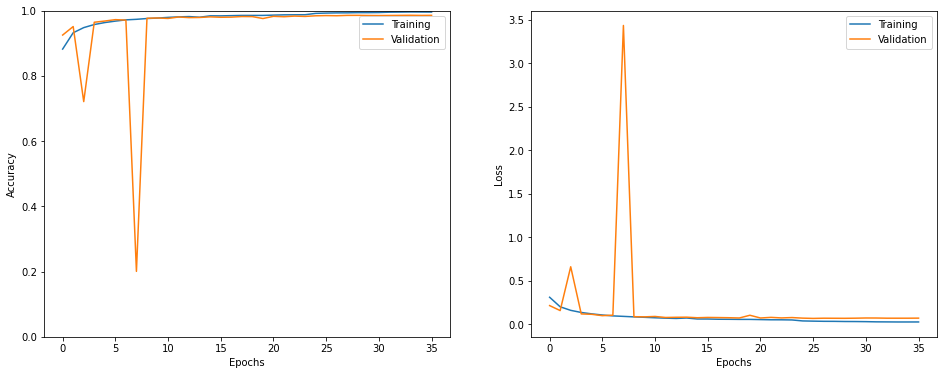

In [18]:
##%% DISPLAYING PLOTS

def show_history(h):
    epochs_trained = len(h.history['loss'])
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_accuracy'), label='Validation')
    plt.ylim([0., 1.])
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_loss'), label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig('CNN_history3.png')
    
    plt.show()
    
show_history(h)


##%%

In [19]:
import pandas as pd

hist_df = pd.DataFrame(h.history) 
hist_csv_file = 'Retrain2_1-4.csv'
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)

In [25]:
import gc
del X_train_tensor
gc.collect()

1100

In [26]:
gpus = tf.config.experimental.list_physical_devices('GPU')
print("GPUs disponibles:", gpus)

# Obtener memoria de la GPU 0
if gpus:
    info = tf.config.experimental.get_memory_info('GPU:0')
    print(f"Memoria usada actualmente: {info['current']/1024/1024:.2f} MB")
    print(f"Pico de memoria: {info['peak']/1024/1024:.2f} MB")


GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memoria usada actualmente: 1873.39 MB
Pico de memoria: 21268.81 MB


In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, plot_confusion_matrix

y_pred = model.predict( [X_test,X_test,X_test, X_test])
print("prediction shape:", y_pred.shape)
print("test shape:", y_test.shape)
y_pred = np.squeeze(y_pred, 1)
print(y_pred)
y_pred = [1. if i> 0.50 else 0. for i in y_pred]
#print(y_pred)
#print("prediction shape:", y_pred.shape)

802/802 [==============================] - 71s 87ms/step
prediction shape: (25664, 1)
test shape: (25664,)
[0.0038235  0.00663959 0.99476963 ... 0.00214209 0.00708688 0.9876847 ]


<AxesSubplot:>

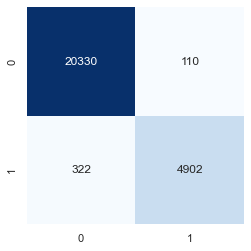

In [28]:
M = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = M.ravel()
# plotting the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns; sns.set_theme()

matrix_confusion = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix_confusion, square=True, annot=True, cmap='Blues', fmt='d', cbar=False)


print('X_test shape:',X_test.shape, type(X_test))
print('y_test shape:',y_test.shape, type(y_test))
